# 4.6.1 从平面流到Lorenz系统

## 学习目标与先修知识

能说明平面自治流定理的条件，求 Lorenz 平衡（equilibrium）和雅可比矩阵（Jacobian matrix），区分精确平衡与局部稳定。

先修：4.1.3 的吸引集合、4.2 的周期运动、3.4 的雅可比矩阵与局部稳定；4.5 的稳定性条件。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

细胞节律的低维模型（model）可能周期运动，也可能表现不规则。为什么连续时间中仅仅把一维模型改成二维，还不够解释所有不规则现象？我们借用一个公开的三维机制模型理解维数与假设。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
rho_values=[.5,10,28]
for rho in rho_values:
    fixed=[] if rho<=1 else [(s*math.sqrt((8/3)*(rho-1)),s*math.sqrt((8/3)*(rho-1)),rho-1) for s in [-1,1]]
    print("rho =",rho,"平衡：",[(0,0,0),*fixed])

rho = 0.5 平衡： [(0, 0, 0)]
rho = 10 平衡： [(0, 0, 0), (-4.898979485566356, -4.898979485566356, 9), (4.898979485566356, 4.898979485566356, 9)]
rho = 28 平衡： [(0, 0, 0), (-8.48528137423857, -8.48528137423857, 27), (8.48528137423857, 8.48528137423857, 27)]


## 模型假设

洛伦兹系统（Lorenz system）来自对热对流方程的低模态（mode）截断。x 表示对流强度，y、z 是温度场模态幅度；x 的正负表示对流方向。σ、ρ、β、状态（state）和 τ 均按既定缩放无量纲（dimensionless）化；参数（parameter）取 σ=10、β=8/3、ρ=.5/10/28，用这三组参数比较平衡与绕行运动。

## 数学解释与推导

**庞加莱–本迪克松定理（Poincaré–Bendixson theorem）的限定版本**：平面自治光滑流的一个前向轨迹（trajectory）留在紧集（compact set）内，且其极限（limit）集不含平衡点，则该极限集是周期轨道。这里的极限集是 t→∞ 时可被轨迹反复任意接近的点的集合。证明为拓展；结论不能套到离散映射，也不能省略无平衡点条件。二维受迫系统加入驱动相位（phase）后通常变为三维自治系统（autonomous system），不受这条平面限制。

三维允许更丰富的运动，但三维本身不保证混沌（chaos）。Lorenz 方程是
$$\dot x=\sigma(y-x),\quad\dot y=\rho x-y-xz,\quad\dot z=xy-\beta z.$$
令右端为零，由第一式 y=x。原点总是平衡；若 x≠0，第二式得 z=ρ−1，第三式得 x²=β(ρ−1)。因此 ρ>1 时另有同号的一对平衡。
$$J=\begin{pmatrix}-\sigma&\sigma&0\\\rho-z&-1&-x\\y&x&-\beta\end{pmatrix}.$$
原点有特征值（eigenvalue） −β，另外两个满足 λ²+(σ+1)λ+σ(1−ρ)=0；ρ<1 时实部均负，ρ>1 时有一正根。非零点的特征多项式为 λ³+(σ+β+1)λ²+β(σ+ρ)λ+2σβ(ρ−1)。计算特征值检查 ρ=10、28 时的平衡稳定性。精确平衡无论稳定与否都应保持不动。

对称变换 (x,y,z)→(−x,−y,z) 保持方程：前两个导数（derivative）换号，第三个不变。它提供无需另一积分器的独立核验。

## 核心实现

RK4 的四阶段及阶数在下一节展开；此处只用它观察固定方程，并以平衡和对称关系核对。

In [3]:
def lorenz_rhs(state, sigma=10., rho=28., beta=8/3):
    x,y,z=state
    return np.array([sigma*(y-x),rho*x-y-x*z,x*y-beta*z])

def lorenz_jacobian(state, sigma=10., rho=28., beta=8/3):
    x,y,z=state
    return np.array([[-sigma,sigma,0],[rho-z,-1,-x],[y,x,-beta]])

def rk4_step(rhs, state, h):
    a=rhs(state)
    b=rhs(state+h*a/2)
    c=rhs(state+h*b/2)
    d=rhs(state+h*c)
    return state+h*(a+2*b+2*c+d)/6

def lorenz_path(initial, sigma=10., rho=28., beta=8/3, h=.01, steps=4000):
    state=np.array(initial,dtype=float)
    rows=[state.copy()]
    for _ in range(steps):
        state=rk4_step(lambda v:lorenz_rhs(v,sigma,rho,beta),state,h)
        if not np.all(np.isfinite(state)):
            raise ValueError('数值结果非有限，请减小步长并检查参数。')
        rows.append(state.copy())
    return np.array(rows)

## 对照实验

C:\Users\10149\AppData\Local\Temp\ipykernel_31760\4206247271.py:8: UserWarning: The figure layout has changed to tight
  fig.tight_layout();plt.show()


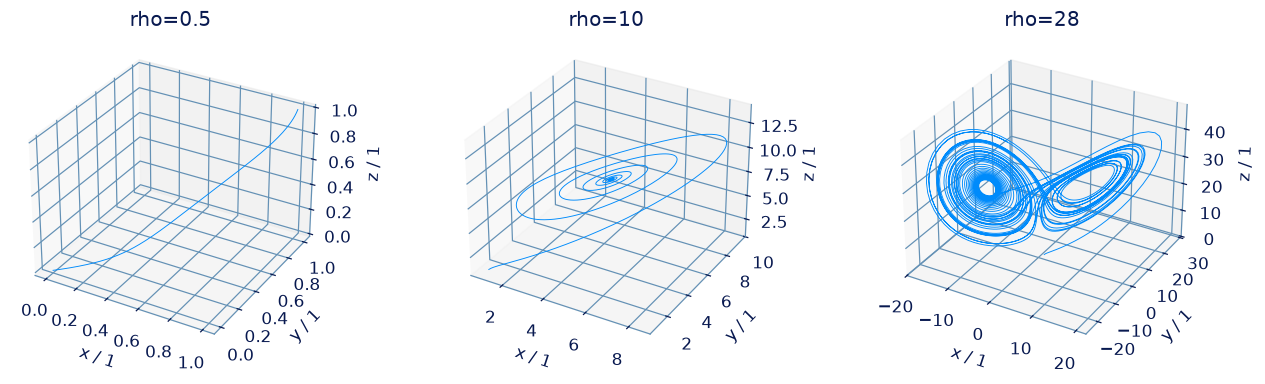

| rho | 所选平衡的最大特征值实部 |
| --- | --- |
| 0.5 | -0.4751 |
| 10 | -0.5955 |
| 28 | 0.094 |

In [4]:

fig,axes=plt.subplots(1,3,figsize=(12,3.6),subplot_kw={'projection':'3d'})
rows=[]
for ax,rho in zip(axes,rho_values):
    path=lorenz_path([1,1,1],rho=rho,h=.01,steps=4000)
    ax.plot(*path.T,color=BLUE,lw=.6);ax.set(xlabel='x / 1',ylabel='y / 1',zlabel='z / 1',title=f'rho={rho}')
    fixed=[0,0,0] if rho<1 else [math.sqrt((8/3)*(rho-1))]*2+[rho-1]
    rows.append([rho,round(float(max(np.real(np.linalg.eigvals(lorenz_jacobian(fixed,rho=rho))))),4)])
fig.tight_layout();plt.show()
display(Markdown(show_table(['rho','所选平衡的最大特征值实部'],rows)))

## 结果解释

相同普通初值（initial condition）在三组参数下呈现不同运动：ρ=.5 靠近原点，ρ=10 靠近一个非零平衡，ρ=28 的有限轨迹持续绕行。三幅图的轴范围分别适配轨迹，运动幅度应结合坐标刻度比较。

### 独立核对

In [5]:
for rho in [.5,10,28]:
    assert np.array_equal(lorenz_path([0,0,0],rho=rho,steps=100),np.zeros((101,3)))
    if rho>1:
        a=math.sqrt((8/3)*(rho-1));p=np.array([a,a,rho-1])
        assert np.max(abs(lorenz_rhs(p,rho=rho)))<1e-12
for state in [[1,2,3],[-4,2,7],[0,0,0]]:
    v=np.array(state);sign=np.array([-1,-1,1])
    assert np.allclose(lorenz_rhs(sign*v),sign*lorenz_rhs(v))
    eps=1e-5;numeric=np.column_stack([(lorenz_rhs(v+eps*e)-lorenz_rhs(v-eps*e))/(2*eps) for e in np.eye(3)])
    assert np.max(abs(numeric-lorenz_jacobian(v)))<1e-7
print('平衡、对称与独立差分 Jacobian 检查通过。')

平衡、对称与独立差分 Jacobian 检查通过。


[观察轨迹、距离与定向截面](http://127.0.0.1:8000/chapters/04-06-连续时间混沌与奇异吸引子/explore/)：分别改变初值与计算精度，再对照本节推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：平面定理适用在哪里

采用本节给出的庞加莱–本迪克松定理（Poincaré–Bendixson theorem）限定版本。哪项正确？

- **A.** 平面自治光滑流的前向轨迹（trajectory）留在紧集（compact set），且其极限（limit）集不含平衡（equilibrium）点时，极限集是周期轨道。
- **B.** 任意二维周期受迫系统都只能有周期解。
- **C.** 三维自治系统（autonomous system）一定混沌（chaos）。
- **D.** 不含平衡点这项可以无条件删除。

[作答：平面定理适用在哪里](http://127.0.0.1:8000/chapters/04-06-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%A5%87%E5%BC%82%E5%90%B8%E5%BC%95%E5%AD%90/practice/?question=p04-plane-autonomous)

### 第 2 题 · 多项选择题：平衡的位置与变量含义

洛伦兹系统（Lorenz system）使用正参数（parameter） σ、ρ、β。哪些说法成立？

- **A.** 原点对所有正参数都是平衡（equilibrium）。
- **B.** ρ>1 时有两个非零平衡，其 x、y 必须同号。
- **C.** x<0 表示负的所追踪物质总量（tracked amount）。
- **D.** ρ=1 时另有两个与原点不同的平衡。

[作答：平衡的位置与变量含义](http://127.0.0.1:8000/chapters/04-06-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%A5%87%E5%BC%82%E5%90%B8%E5%BC%95%E5%AD%90/practice/?question=p04-lorenz-equilibria)

### 第 3 题 · Python 计算题：从方程计算向量场与雅可比矩阵

洛伦兹系统（Lorenz system）为 x′=σ(y−x)、y′=ρx−y−xz、z′=xy−βz。计算此状态（state）的导数（derivative）向量（vector）及局部线性化（linearization）矩阵（matrix）。

**函数与代码模板**

```python
def solve(
    sigma: float,
    rho: float,
    beta: float,
    state: list[float],
) -> tuple[list[float], list[list[float]]]:
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `sigma` | `float` | 正参数（parameter） σ。 | 1 |
| `rho` | `float` | 正参数 ρ。 | 1 |
| `beta` | `float` | 正参数 β。 | 1 |
| `state` | `list[float]` | 状态（state） [x,y,z]。 | 1 |

**返回值**

按以下顺序返回元组：(rates, jacobian)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rates` | `list[float]` | [x′,y′,z′]。 | 每单位 τ |
| `jacobian` | `list[list[float]]` | 按状态 x,y,z 顺序的 3×3 雅可比矩阵（Jacobian matrix）。 | 每单位 τ |

**计算规则**

逐行按三条方程及其对 x,y,z 的偏导（partial derivative）计算；返回 (rates,jacobian)。

**约束与边界**

- 所有数值有限，不修改输入（input）列表。
- 0<σ≤20，0<ρ≤40，0<β≤5；状态各分量绝对值≤60。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| sigma | 正参数（parameter） σ。 | 10 | 1 |
| rho | 正参数 ρ。 | 28 | 1 |
| beta | 正参数 β。 | 2 | 1 |
| state | 状态（state） [x,y,z]。 | [1, 2, 3] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
sigma = 10
rho = 28
beta = 2
state = [1, 2, 3]

result = solve(sigma, rho, beta, state)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| rates | [x′,y′,z′]。 | [10, 23, -4] | 每单位 τ |
| jacobian | 按状态 x,y,z 顺序的 3×3 雅可比矩阵（Jacobian matrix）。 | [[-10, 10, 0.0], [25, -1.0, -1], [2, 1, -2]] | 每单位 τ |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([10, 23, -4],
                   [[-10, 10, 0.0],
                    [25, -1.0, -1],
                    [2, 1, -2]])
```

**样例解释**

第一分量为 10(2−1)=10，第二为 28−2−3=23，第三为 2−6=−4。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-08。

[作答：从方程计算向量场与雅可比矩阵](http://127.0.0.1:8000/chapters/04-06-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%A5%87%E5%BC%82%E5%90%B8%E5%BC%95%E5%AD%90/practice/?question=p04-lorenz-field)

### 第 4 题 · 单项选择题：精确平衡不是稳定性检验

ρ=28 时从精确原点出发，程序一直返回零。正确解释是什么？

- **A.** 这是平衡（equilibrium）解；判断稳定性还需检查扰动与雅可比矩阵（Jacobian matrix）。
- **B.** 这证明原点吸引所有邻近初值（initial condition）。
- **C.** 应偷偷加入随机扰动使其画出蝴蝶。
- **D.** 只要有不稳定平衡就不可能有吸引子（attractor）。

[作答：精确平衡不是稳定性检验](http://127.0.0.1:8000/chapters/04-06-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%A5%87%E5%BC%82%E5%90%B8%E5%BC%95%E5%AD%90/practice/?question=p04-lorenz-local-scope)

### 参考阅读

[MIT 非线性动力学讲义](https://ocw.mit.edu/courses/12-006j-nonlinear-dynamics-chaos-fall-2022/pages/lecture-notes/)：第 15—16 讲的截面，第 19 讲的奇异几何，第 20—21 讲的 Lorenz 方程，第 24 讲的增长率。核心推导与实验均已写在本节。